# Maintenance prédictive des ascenseurs
### AFEO Ascenseurs & Automatisme

Ce notebook estime le **risque de panne** d'un ascenseur à partir de son historique d'interventions.


**Démarche :** chargement & fusion → audit → périmètre ascenseurs → fenêtres glissantes →
deux cibles (tout dépannage / défaillance matérielle) → feature engineering →
modélisation → validation temporelle → importance des variables → limites.

In [ ]:
import re
import numpy as np
import pandas as pd
from lxml import etree
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None, 'display.width', 200)

DATA_DIR = '../donnees'
FICHIER_PARC  = f'{DATA_DIR}/Appareil-2026-07-16_0843.xls'
FICHIERS_HIST = [f'{DATA_DIR}/Suivi_des_Rapports-2026-07-16_0932.xls',   # 2025
                 f'{DATA_DIR}/Suivi_des_Rapports-2026-07-16_0855.xls']   # 2026

## 1. Chargement des exports Binsa

Les `.xls` de Binsa sont au format XML Spreadsheet 2003. On les parse en corrigeant les `&` non échappés,
puis on rend les noms de colonnes uniques (le fichier contient deux colonnes « Type »).

In [2]:
SS = "{urn:schemas-microsoft-com:office:spreadsheet}"

def lire_binsa(path):
    raw = open(path, "rb").read().decode("utf-8")
    raw = re.sub(r"&(?!(amp|lt|gt|quot|apos|#\d+|#x[0-9a-fA-F]+);)", "&amp;", raw)
    root = etree.fromstring(raw.encode("utf-8"))
    table = root.find(f".//{SS}Worksheet").find(f"{SS}Table")
    rows = []
    for row in table.findall(f"{SS}Row"):
        cells, ci = [], 0
        for cell in row.findall(f"{SS}Cell"):
            idx = cell.get(f"{SS}Index")
            if idx: ci = int(idx) - 1
            data = cell.find(f"{SS}Data")
            while len(cells) < ci: cells.append(None)
            cells.append(data.text if data is not None else None); ci += 1
        rows.append(cells)
    header = rows[1]
    data = [r for r in rows[2:] if any(c is not None for c in r)]
    data = [r + [None]*(len(header)-len(r)) if len(r) < len(header) else r[:len(header)] for r in data]
    return pd.DataFrame(data, columns=header)

def noms_uniques(df):
    cols = pd.Series(df.columns)
    for d in cols[cols.duplicated()].unique():
        idx = cols[cols == d].index
        for i, x in enumerate(idx):
            if i: cols[x] = f"{d}_{i}"
    df.columns = cols
    return df

parc = lire_binsa(FICHIER_PARC)
hist = pd.concat([noms_uniques(lire_binsa(f)) for f in FICHIERS_HIST], ignore_index=True)
hist = hist.drop_duplicates(subset=["Exercice", "Nº Rapport", "Référence", "Date"])
hist["Date_dt"] = pd.to_datetime(hist["Date"], errors="coerce")
hist["TypeRapport"] = hist["Type"]  # type de rapport (Maintenance / Intervention / ...)
print("Parc      :", parc.shape)
print("Historique:", hist.shape, "|", hist["Date_dt"].min().date(), "->", hist["Date_dt"].max().date())

Parc      : (3744, 60)
Historique: (48435, 32) | 2024-11-26 -> 2026-07-16


## 2. Audit rapide

Volumétrie, plage temporelle, recouvrement parc ↔ historique. Alimente la partie *faisabilité* du mémoire.

Nb interventions : 48435
Types de rapport : {'Maintenance': 25651, 'Intervention': 14616, 'Rapport': 3304, 'Bon Sécurité': 2696, 'O.T.': 1777, 'Étude Sécurité': 225, 'F': 166}
Recouvrement     : 3613/3744 (96.5% du parc)


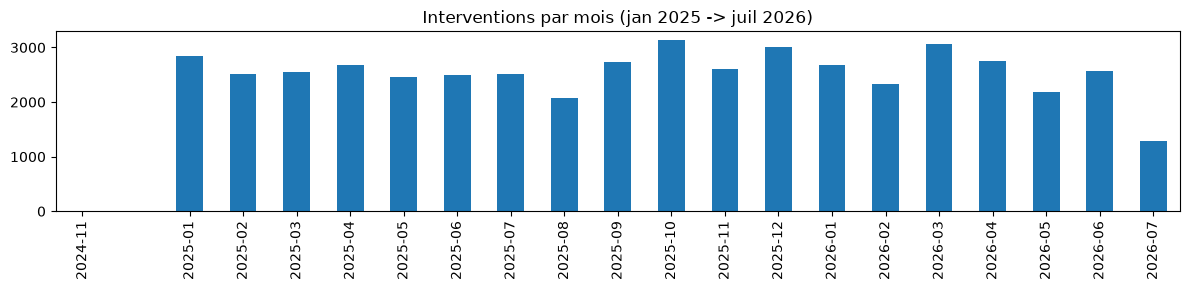

In [3]:
print("Nb interventions :", len(hist))
print("Types de rapport :", hist['TypeRapport'].value_counts().to_dict())
refs_parc, refs_hist = set(parc['Référence'].dropna()), set(hist['Référence'].dropna())
print(f"Recouvrement     : {len(refs_parc & refs_hist)}/{len(refs_parc)} "
      f"({100*len(refs_parc & refs_hist)/len(refs_parc):.1f}% du parc)")

ax = hist['Date_dt'].dt.to_period('M').value_counts().sort_index().plot(kind='bar', figsize=(12,3))
ax.set_title("Interventions par mois (jan 2025 -> juil 2026)"); ax.set_xlabel(""); plt.tight_layout(); plt.show()

## 3. Périmètre : ascenseurs uniquement

In [4]:
asc_refs = set(parc[parc['Type'] == 'Ascenseur']['Référence'].dropna())
print("Ascenseurs :", len(asc_refs))

Ascenseurs : 1855


## 4. Construction d'un « fold » (fenêtre observation → fenêtre prédiction)

On définit une fonction qui, pour un couple de fenêtres, produit un jeu de données : une ligne par ascenseur,
ses variables explicatives (calculées sur l'observation) et ses deux étiquettes (calculées sur la prédiction).

- **`target_all`** : au moins un dépannage curatif sur la fenêtre de prédiction.
- **`target_mat`** : au moins une *vraie défaillance matérielle* (on exclut coupure EDF, malveillance,
  mauvaise utilisation, etc.).

In [5]:
CAUSES_MATERIELLES = {'En défaut', 'Défaillance matériel', 'Matériel vétuste',
                      'déréglage/desserage', 'Bruit'}

parc_asc = (parc[parc['Type'] == 'Ascenseur'][['Référence', 'Prix Maint.', 'Type contrat',
             'Fréquence Maintenance', 'NomAgence', 'Date de debut de contrat']]
            .drop_duplicates('Référence').set_index('Référence'))
parc_asc['prix_maint'] = pd.to_numeric(parc_asc['Prix Maint.'], errors='coerce')

def variables_observation(g):
    dep = g[g['TypeRapport'] == 'Intervention']
    return pd.Series({
        'nb_interv_total':    len(g),
        'nb_depannages':      len(dep),
        'nb_maintenances':    (g['TypeRapport'] == 'Maintenance').sum(),
        'nb_anomalies':       (g['Anomalie'] == 'Anomalie').sum(),
        'nb_defaillance_mat': dep['Origine'].isin(CAUSES_MATERIELLES).sum(),
        'nb_en_defaut':       (dep['Origine'] == 'En défaut').sum(),
        'nb_vetuste':         (dep['Origine'] == 'Matériel vétuste').sum(),
    })

def construire_fold(obs_start, obs_end, pred_start, pred_end):
    obs  = hist[(hist['Date_dt'] >= obs_start) & (hist['Date_dt'] < obs_end)
                & (hist['Référence'].isin(asc_refs))]
    pred = hist[(hist['Date_dt'] >= pred_start) & (hist['Date_dt'] < pred_end)
                & (hist['Référence'].isin(asc_refs))]
    F = obs.groupby('Référence').apply(variables_observation, include_groups=False)
    dep = pred[pred['TypeRapport'] == 'Intervention']
    ta = set(dep['Référence'])
    tm = set(dep[dep['Origine'].isin(CAUSES_MATERIELLES)]['Référence'])
    ds = parc_asc.join(F).fillna({c: 0 for c in F.columns})
    ds['age'] = (pred_start.year
                 - pd.to_datetime(ds['Date de debut de contrat'], errors='coerce').dt.year).clip(lower=0)
    ds['target_all'] = ds.index.isin(ta).astype(int)
    ds['target_mat'] = ds.index.isin(tm).astype(int)
    return ds

## 5. Deux folds temporels

- **Entraînement** — observation jan→sep 2025, prédiction **T4 2025**.
- **Test** — observation avr→déc 2025, prédiction **T1 2026** (*strictement postérieur*).

Chaque fold garde 9 mois d'observation + 3 mois de prédiction. Le test porte sur un trimestre futur
que le modèle n'a jamais vu : c'est la vraie mesure de généralisation.

In [6]:
T = pd.Timestamp
train = construire_fold(T('2025-01-01'), T('2025-10-01'), T('2025-10-01'), T('2026-01-01'))
test  = construire_fold(T('2025-04-01'), T('2026-01-01'), T('2026-01-01'), T('2026-04-01'))

for nom, d in [('TRAIN (préd. T4-2025)', train), ('TEST  (préd. T1-2026)', test)]:
    print(f"{nom}: {len(d)} ascenseurs | "
          f"pannes all={100*d['target_all'].mean():.1f}%  mat={100*d['target_mat'].mean():.1f}%")

TRAIN (préd. T4-2025): 1855 ascenseurs | pannes all=38.4%  mat=29.7%
TEST  (préd. T1-2026): 1855 ascenseurs | pannes all=40.1%  mat=29.2%


## 6. Modélisation & validation temporelle

On entraîne sur `train`, on évalue sur `test`. Deux modèles : régression logistique (référence interprétable)
et Random Forest. Métriques adaptées : **AUC, précision, rappel, F1** (jamais l'accuracy seule).

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, RocCurveDisplay

FEATURES = ['age','prix_maint','nb_interv_total','nb_depannages','nb_maintenances',
            'nb_anomalies','nb_defaillance_mat','nb_en_defaut','nb_vetuste']

def valider(target):
    Xtr, ytr = train[FEATURES].fillna(0), train[target]
    Xte, yte = test[FEATURES].fillna(0),  test[target]
    print(f"===== {target}  (positifs test: {100*yte.mean():.1f}%) =====")
    modeles = {
        'Régression logistique': make_pipeline(StandardScaler(),
                    LogisticRegression(max_iter=1000, class_weight='balanced')),
        'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced',
                    random_state=42, n_jobs=-1),
    }
    for nom, m in modeles.items():
        m.fit(Xtr, ytr)
        p, proba = m.predict(Xte), m.predict_proba(Xte)[:, 1]
        print(f"  {nom:24s} AUC={roc_auc_score(yte,proba):.3f}  "
              f"Précision={precision_score(yte,p):.3f}  Rappel={recall_score(yte,p):.3f}  "
              f"F1={f1_score(yte,p):.3f}")
    return modeles

modeles_all = valider('target_all'); print()
modeles_mat = valider('target_mat')

===== target_all  (positifs test: 40.1%) =====
  Régression logistique    AUC=0.654  Précision=0.544  Rappel=0.534  F1=0.539
  Random Forest            AUC=0.642  Précision=0.525  Rappel=0.532  F1=0.529

===== target_mat  (positifs test: 29.2%) =====
  Régression logistique    AUC=0.661  Précision=0.421  Rappel=0.515  F1=0.463
  Random Forest            AUC=0.647  Précision=0.417  Rappel=0.445  F1=0.430


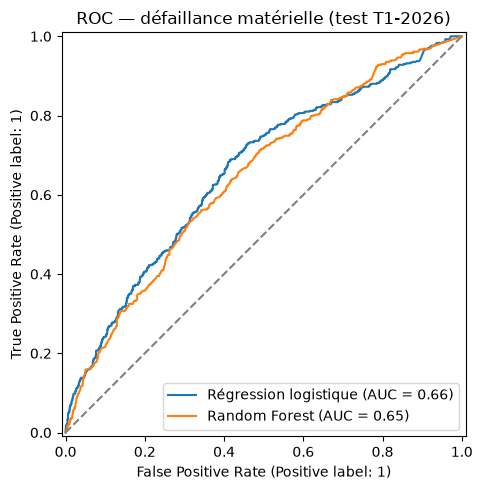

In [8]:
# Courbe ROC (défaillance matérielle, sur la période test future)
fig, ax = plt.subplots(figsize=(5,5))
for nom, m in modeles_mat.items():
    RocCurveDisplay.from_estimator(m, test[FEATURES].fillna(0), test['target_mat'], name=nom, ax=ax)
ax.plot([0,1],[0,1],'--',c='grey'); ax.set_title("ROC — défaillance matérielle (test T1-2026)")
plt.tight_layout(); plt.show()

## 7. Importance des variables

Quels facteurs annoncent le plus une panne ? Souvent le résultat le plus actionnable pour AFEO.

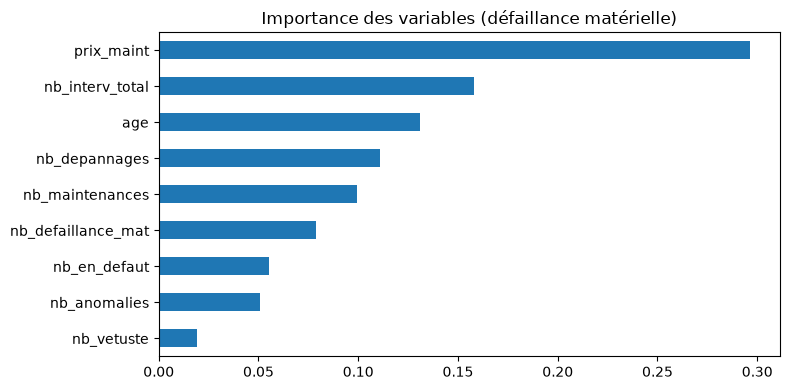

prix_maint            0.296572
nb_interv_total       0.157867
age                   0.131066
nb_depannages         0.111096
nb_maintenances       0.099233
nb_defaillance_mat    0.078932
nb_en_defaut          0.055487
nb_anomalies          0.050754
nb_vetuste            0.018994
dtype: float64

In [9]:
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                            random_state=42, n_jobs=-1).fit(train[FEATURES].fillna(0), train['target_mat'])
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
imp.plot(kind='barh', figsize=(8,4), title="Importance des variables (défaillance matérielle)")
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False)

## 8. Limites & pistes d'amélioration

**Limites à assumer :**
- L'« âge » dérive de la *date de début de contrat* (ancienneté AFEO), pas de l'âge réel de l'ascenseur.
- Pas de marque/modèle constructeur dans l'export → prédicteur potentiellement fort manquant.
- Le parc n'inclut que les appareils encore *sous contrat* (pas de résiliés).
- Un même ascenseur apparaît dans train et test (avec des fenêtres différentes) : réaliste pour un
  re-scoring trimestriel du parc, mais à mentionner.

**Pistes :**
- **Fenêtres glissantes multiples** pour augmenter le nombre d'exemples d'entraînement.
- **Gradient boosting** (XGBoost / LightGBM) + réglage d'hyperparamètres.
- Enrichissement : délai depuis la dernière panne, saisonnalité, **NLP** sur les commentaires d'anomalie.
- Ajustement du **seuil de décision** selon l'arbitrage précision/rappel voulu par AFEO.